#### Linear Regression with Transformed and Interaction Features

In a linear regression model, the target is modeled as a linear combination of fitted coefficients. The features themselves need not be linear functions of the original variables. For three predictors, a model containing all terms through second order is

$$y = w_0 + w_1x_1 + w_2x_2 + w_3x_3 + w_4x_1^2 + w_5x_2^2 + w_6x_3^2 + w_7x_1x_2 + w_8x_1x_3 + w_9x_2x_3.$$

Here $y$ is the target, $x_1$, $x_2$, and $x_3$ are the predictors, and $w_0$ through $w_9$ are fitted coefficients. Although this is nonlinear in the predictors, it remains a *linear regression* because it is linear in the coefficients.

When interpreting such a model, we normally respect the **hierarchy principle**: if an interaction or transformed term is retained, its associated lower-order terms should generally remain as well, even when an individual lower-order p-value is not small.

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import statsmodels.formula.api as smf
import numpy as np
from scipy.stats import f

#Reduced model RSS: 541.211
#Reduced model R^2: 0.903
#Reduced model adjusted R^2: 0.902
#Reduced model F statistic: 912.686

RSS_reduced_linear = 541.211
R2_reduced_linear = 0.903
R2_adj_reduced_linear = 0.902
F_statistic_reduced_linear = 912.686

# Get the data
advert = pd.read_csv('advertising.csv')
print(advert.head())

      TV  Radio  Newspaper  Sales
0  230.1   37.8       69.2   22.1
1   44.5   39.3       45.1   10.4
2   17.2   45.9       69.3   12.0
3  151.5   41.3       58.5   16.5
4  180.8   10.8       58.4   17.9


The first step is to look at the data.  A reasonable first step is to plot sales vs. each of the features, individually.

Text(0, 0.5, 'Sales')

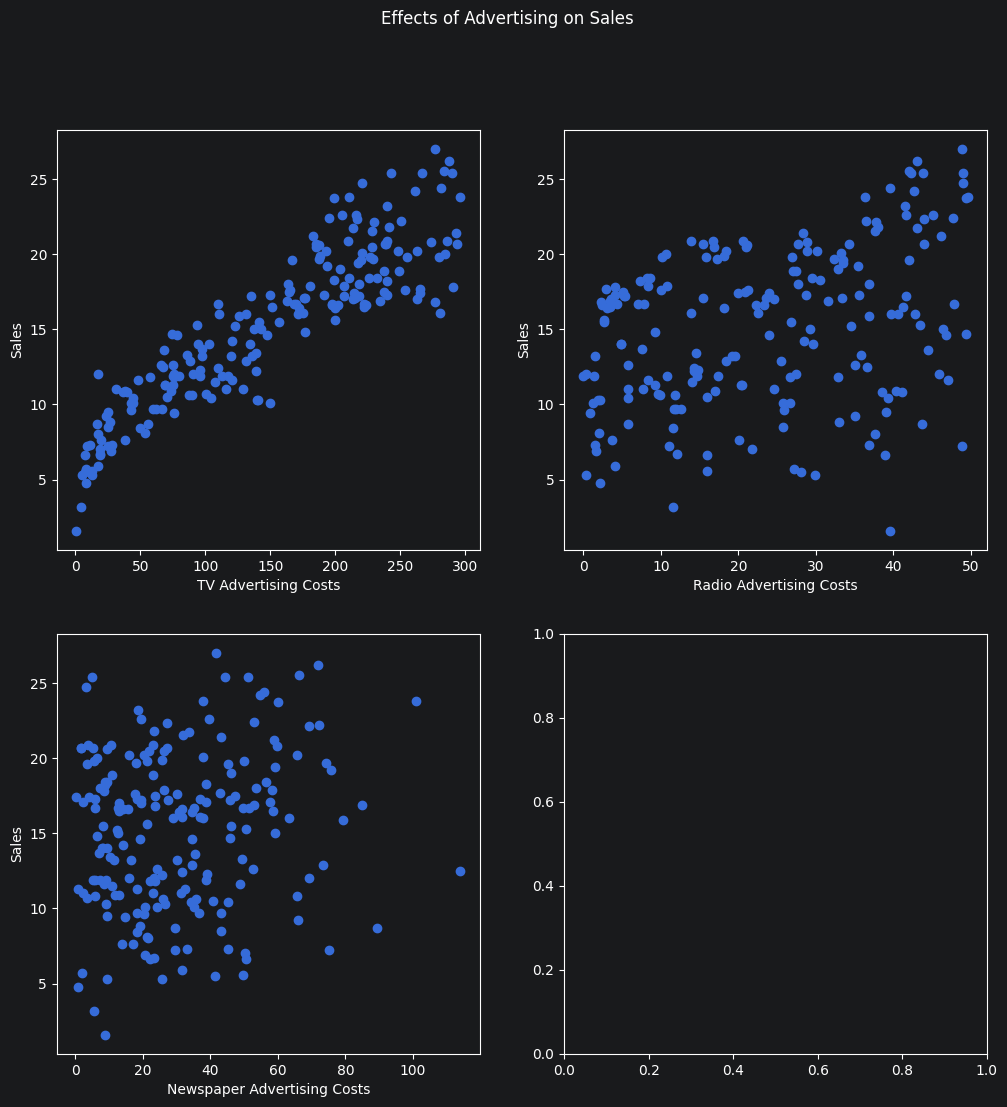

In [2]:
# Look at the data!  Create plots of Sales vs. each variable
fig, ax = plt.subplots(2, 2, figsize=(12,12))
fig.suptitle("Effects of Advertising on Sales")
ax[0][0].plot(advert['TV'], advert['Sales'], 'o', label = "Data")           # scatter plot showing actual data
ax[0][0].set_xlabel('TV Advertising Costs')
ax[0][0].set_ylabel('Sales')

ax[0][1].plot(advert['Radio'], advert['Sales'], 'o', label = "Data")           # scatter plot showing actual data
ax[0][1].set_xlabel('Radio Advertising Costs')
ax[0][1].set_ylabel('Sales')

ax[1][0].plot(advert['Newspaper'], advert['Sales'], 'o', label = "Data")           # scatter plot showing actual data
ax[1][0].set_xlabel('Newspaper Advertising Costs')
ax[1][0].set_ylabel('Sales')

      TV  Radio  Newspaper  Sales  Sales_Quadratic  Quadratic_Residual
0  230.1   37.8       69.2   22.1        21.763764            0.336236
1   44.5   39.3       45.1   10.4        10.384665            0.015335
2   17.2   45.9       69.3   12.0         9.079240            2.920760
3  151.5   41.3       58.5   16.5        18.383458           -1.883458
4  180.8   10.8       58.4   17.9        15.875701            2.024299
                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.936
Model:                            OLS   Adj. R-squared:                  0.932
Method:                 Least Squares   F-statistic:                     306.2
Date:                Mon, 14 Sep 2026   Prob (F-statistic):          4.97e-108
Time:                        15:24:33   Log-Likelihood:                -342.10
No. Observations:                 200   AIC:                             704.2
Df Residuals:        

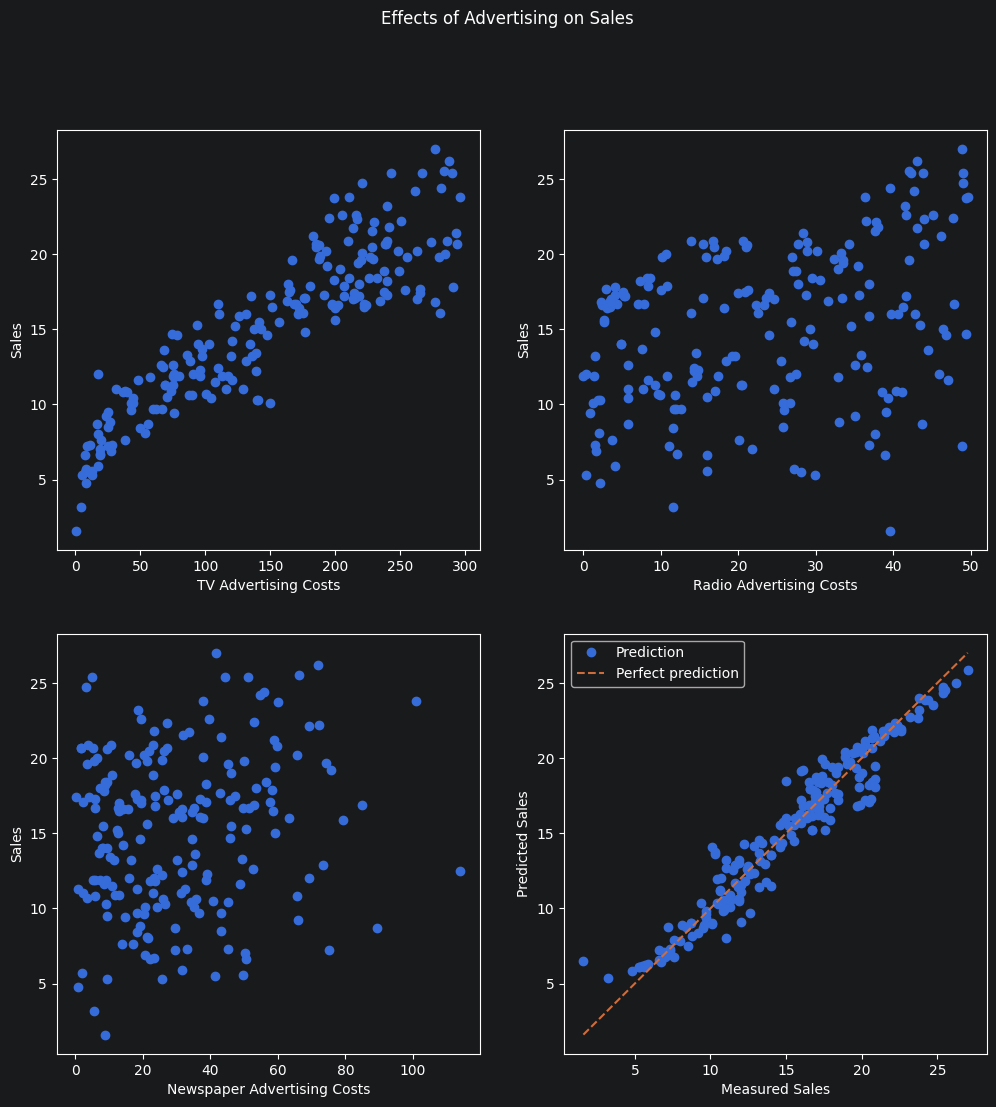

In [3]:
# Fit the full quadratic model, including all two-feature interactions
quadratic_formula = ('Sales ~ TV + Radio + Newspaper + np.power(TV, 2) + '
                     'np.power(Radio, 2) + np.power(Newspaper, 2) + '
                     'TV:Radio + TV:Newspaper + Radio:Newspaper')
model_quadratic = smf.ols(quadratic_formula, data=advert).fit()

advert['Sales_Quadratic'] = model_quadratic.predict()
advert['Quadratic_Residual'] = advert['Sales'] - advert['Sales_Quadratic']
print(advert.head())

# For a multifactor fit, predicted-versus-measured values are more informative than
# plotting predictions against only one predictor.
ax[1][1].plot(advert['Sales'], advert['Sales_Quadratic'], 'o', label='Prediction')
limits = [advert['Sales'].min(), advert['Sales'].max()]
ax[1][1].plot(limits, limits, '--', label='Perfect prediction')
ax[1][1].set_xlabel('Measured Sales')
ax[1][1].set_ylabel('Predicted Sales')
ax[1][1].legend()

print(model_quadratic.summary())
fig

#### Conclusions from the full quadratic model

At the conventional $\alpha=0.05$ threshold, the stored fit shows evidence for the TV linear and quadratic terms, the Radio quadratic term, and the TV–Radio interaction. The linear Radio coefficient by itself has $p=0.184$, so it should not be described as individually significant. None of the Newspaper terms has a small p-value.

The model has $R^2=0.936$ and adjusted $R^2=0.932$. Its large overall F-statistic tests whether the model improves on an intercept-only model; it does not establish that the functional form is correct or that every included term is useful.

Because the model contains $TV^2$, $Radio^2$, and the TV–Radio interaction, the hierarchy principle argues for retaining the corresponding lower-order TV and Radio terms when constructing a reduced model.

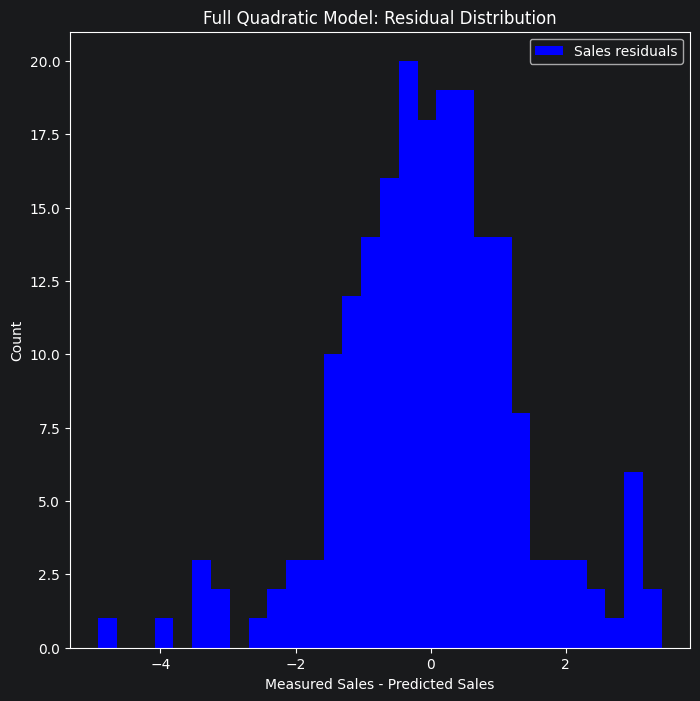

In [4]:
fig, ax = plt.subplots(1, 1, figsize=(8, 8))

ax.hist(advert['Quadratic_Residual'], color='blue', ec='white', bins=30,
        label='Sales residuals')
ax.set_title('Full Quadratic Model: Residual Distribution')
ax.set_xlabel('Measured Sales - Predicted Sales')
ax.set_ylabel('Count')
ax.legend()
plt.show()

In [5]:
print(advert['Quadratic_Residual'].describe())

count    2.000000e+02
mean     1.436731e-12
std      1.341886e+00
min     -4.922012e+00
25%     -7.703587e-01
50%      2.282547e-02
75%      8.061922e-01
max      3.424282e+00
Name: Quadratic_Residual, dtype: float64


In [6]:
# Based on the above results, we should construct the following reduced model, which retains the TV and Radio main effects, the TV^2 and Radio^2 terms, and the TV:Radio interaction.  The Newspaper terms are removed.
reduced_formula = 'Sales ~ TV + Radio + np.power(TV, 2) + np.power(Radio, 2) + TV:Radio'
model_reduced = smf.ols(reduced_formula, data=advert).fit()
print(model_reduced.summary())

# Retain the R^2 and adjusted R^2 values and F statistic for comparison with the square-root model.
RSS_quadratic_reduced = np.sum((advert['Sales'] - advert['Sales_Quadratic'])**2)
R2_quadratic_reduced = model_reduced.rsquared
R2_adj_quadratic_reduced = model_reduced.rsquared_adj
F_statistic_quadratic_reduced = model_reduced.fvalue


                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.935
Model:                            OLS   Adj. R-squared:                  0.933
Method:                 Least Squares   F-statistic:                     559.3
Date:                Mon, 14 Sep 2026   Prob (F-statistic):          3.87e-113
Time:                        15:24:34   Log-Likelihood:                -342.68
No. Observations:                 200   AIC:                             697.4
Df Residuals:                     194   BIC:                             717.1
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              5.1530      0

### Question:  Can we understand the interaction between TV and Radio advertising?

Let's begin by looking at the correlation between TV and Radio advertising costs, as presented in the data.

Text(0, 0.5, 'Newspaper Advertising Costs')

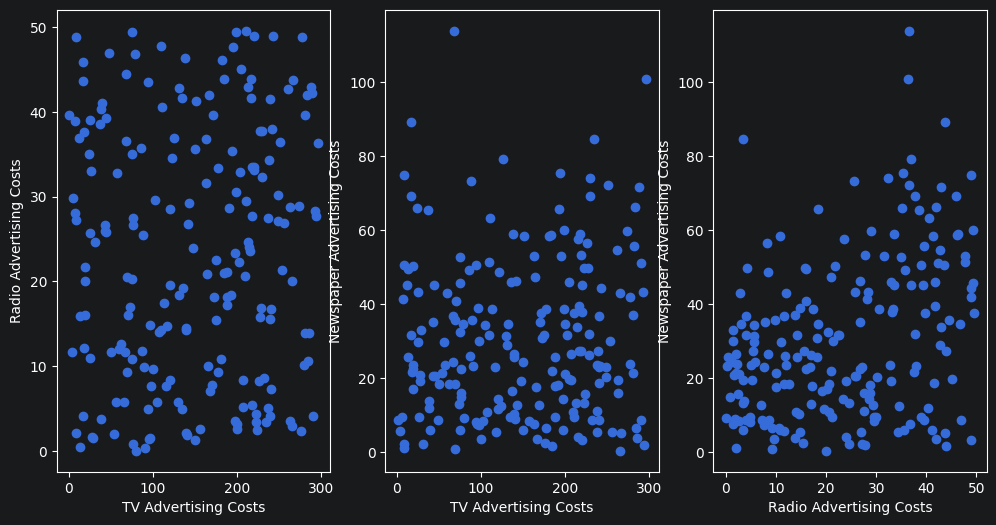

In [7]:
fig, ax = plt.subplots(1, 3, figsize=(12,6))

ax[0].plot(advert['TV'], advert['Radio'], 'o', label = "Data")           # scatter plot showing actual data
ax[0].set_xlabel('TV Advertising Costs')
ax[0].set_ylabel('Radio Advertising Costs')

ax[1].plot(advert['TV'], advert['Newspaper'], 'o', label = "Data")           # scatter plot showing actual data
ax[1].set_xlabel('TV Advertising Costs')
ax[1].set_ylabel('Newspaper Advertising Costs')

ax[2].plot(advert['Radio'], advert['Newspaper'], 'o', label = "Data")           # scatter plot showing actual data
ax[2].set_xlabel('Radio Advertising Costs')
ax[2].set_ylabel('Newspaper Advertising Costs')


                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.938
Model:                            OLS   Adj. R-squared:                  0.935
Method:                 Least Squares   F-statistic:                     317.6
Date:                Mon, 14 Sep 2026   Prob (F-statistic):          1.95e-109
Time:                        15:24:34   Log-Likelihood:                -338.69
No. Observations:                 200   AIC:                             697.4
Df Residuals:                     190   BIC:                             730.4
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              2.7221      0

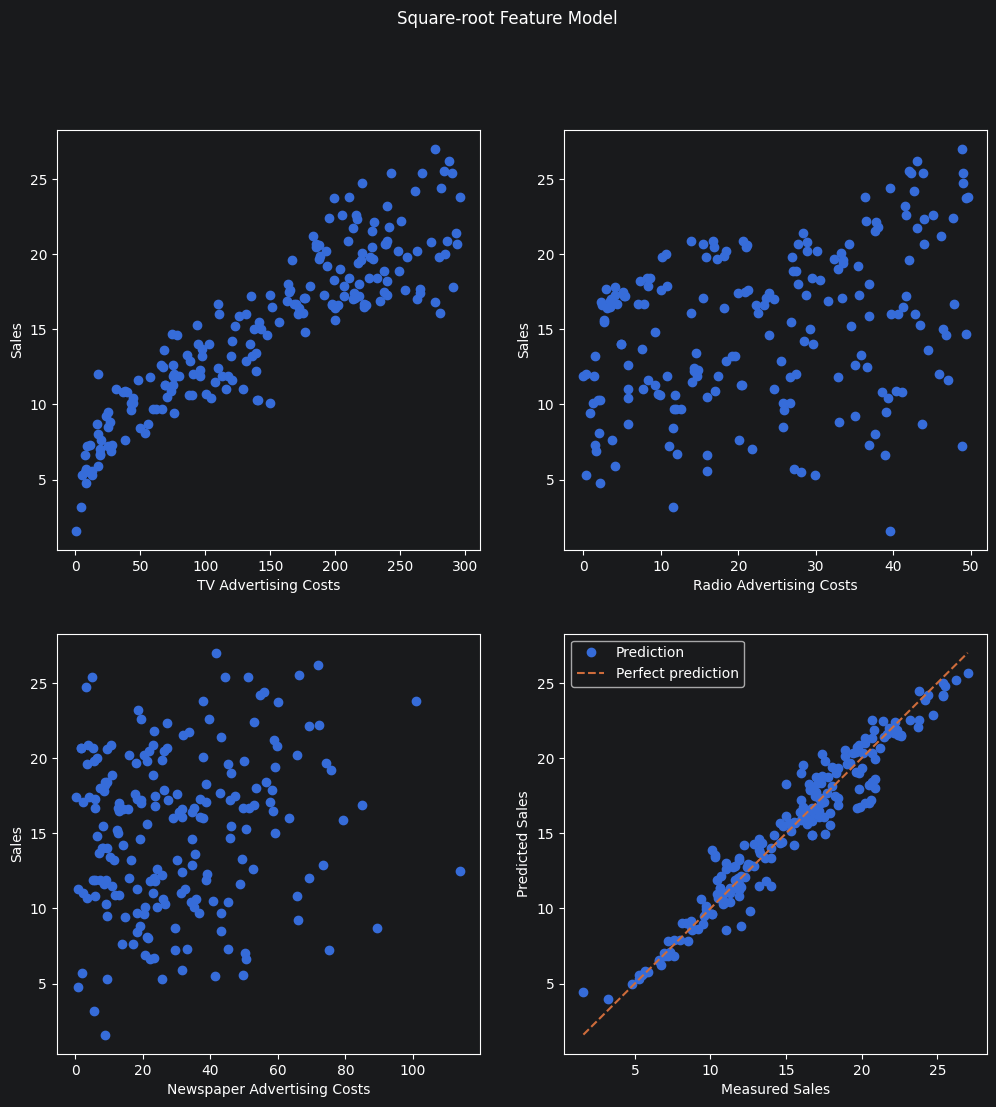

In [8]:
fig, ax = plt.subplots(2, 2, figsize=(12, 12))
fig.suptitle('Square-root Feature Model')
ax[0][0].plot(advert['TV'], advert['Sales'], 'o')
ax[0][0].set_xlabel('TV Advertising Costs')
ax[0][0].set_ylabel('Sales')
ax[0][1].plot(advert['Radio'], advert['Sales'], 'o')
ax[0][1].set_xlabel('Radio Advertising Costs')
ax[0][1].set_ylabel('Sales')
ax[1][0].plot(advert['Newspaper'], advert['Sales'], 'o')
ax[1][0].set_xlabel('Newspaper Advertising Costs')
ax[1][0].set_ylabel('Sales')

sqrt_formula = ('Sales ~ TV + Radio + Newspaper + np.sqrt(TV) + np.sqrt(Radio) + '
                'np.sqrt(Newspaper) + TV:Radio + TV:Newspaper + Radio:Newspaper')
model_sqrt_full = smf.ols(sqrt_formula, data=advert).fit()

advert['Sales_Sqrt_Full'] = model_sqrt_full.predict()
advert['Sqrt_Full_Residual'] = advert['Sales'] - advert['Sales_Sqrt_Full']

ax[1][1].plot(advert['Sales'], advert['Sales_Sqrt_Full'], 'o', label='Prediction')
limits = [advert['Sales'].min(), advert['Sales'].max()]
ax[1][1].plot(limits, limits, '--', label='Perfect prediction')
ax[1][1].set_xlabel('Measured Sales')
ax[1][1].set_ylabel('Predicted Sales')
ax[1][1].legend()

print(model_sqrt_full.summary())


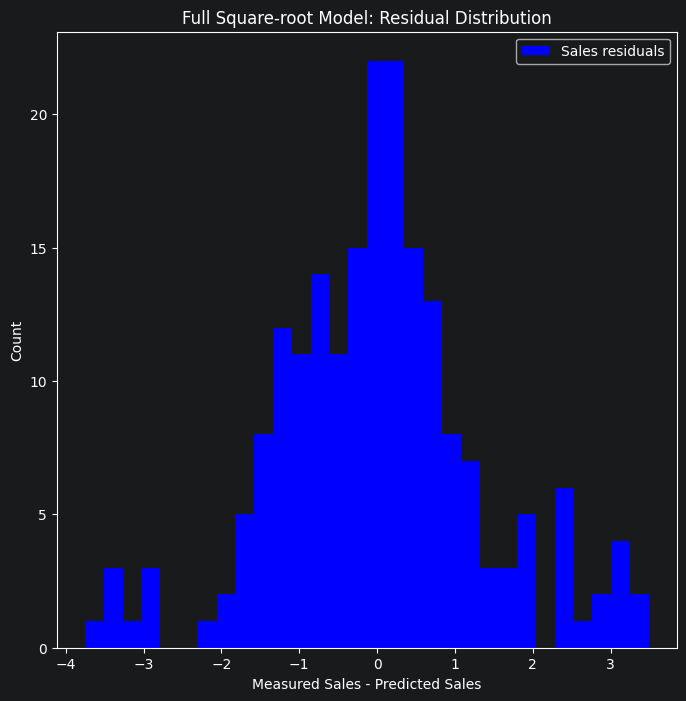

count    2.000000e+02
mean     6.382894e-14
std      1.319170e+00
min     -3.750856e+00
25%     -7.809640e-01
50%      6.527027e-03
75%      6.487572e-01
max      3.488901e+00
Name: Sqrt_Full_Residual, dtype: float64


In [9]:
fig, ax = plt.subplots(1, 1, figsize=(8, 8))

ax.hist(advert['Sqrt_Full_Residual'], color='blue', ec='white', bins=30,
        label='Sales residuals')
ax.set_title('Full Square-root Model: Residual Distribution')
ax.set_xlabel('Measured Sales - Predicted Sales')
ax.set_ylabel('Count')
ax.legend()
plt.show()

print(advert['Sqrt_Full_Residual'].describe())

In [10]:
# Based on the above results, we should construct the following reduced model, which retains the TV and Radio main effects, the square-root terms for TV and Radio, and the TV:Radio interaction.  The Newspaper terms are removed.
reduced_formula = 'Sales ~ TV + Radio + np.sqrt(TV) + np.sqrt(Radio) + TV:Radio'
model_sqrt_reduced = smf.ols(reduced_formula, data=advert).fit()
print(model_sqrt_reduced.summary())

# Retain the R^2 and adjusted R^2 values and F statistic for comparison with the quadratic model.
RSS_sqrt_reduced = np.sum((advert['Sales'] - advert['Sales_Sqrt_Full'])**2)
R2_sqrt_reduced = model_sqrt_reduced.rsquared
R2_adj_sqrt_reduced = model_sqrt_reduced.rsquared_adj
F_statistic_sqrt_reduced = model_sqrt_reduced.fvalue

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.937
Model:                            OLS   Adj. R-squared:                  0.936
Method:                 Least Squares   F-statistic:                     580.6
Date:                Mon, 14 Sep 2026   Prob (F-statistic):          1.31e-114
Time:                        15:24:34   Log-Likelihood:                -339.19
No. Observations:                 200   AIC:                             690.4
Df Residuals:                     194   BIC:                             710.2
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          2.4440      0.786      3.

#### Comparing the two full models

The square-root-feature model has $R^2=0.938$ and adjusted $R^2=0.935$, only slightly larger than the quadratic model. The two fits as written actually contain the same number of fitted coefficients, so the square-root model is **not** a five-parameter alternative to a six-parameter model.

For these stored results, the square-root model has somewhat lower AIC and BIC, which favors it among these two candidates after accounting for their equal parameter counts. That comparison is useful evidence, but it is not definitive proof that one functional form is universally better. Residual diagnostics, physical or empirical justification, and performance on held-out data are also important.

The full square-root fit suggests removing the Newspaper-related terms. To make the following visualization internally consistent, we now fit that reduced hierarchical model explicitly rather than extracting selected coefficients from the full model.

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.937
Model:                            OLS   Adj. R-squared:                  0.936
Method:                 Least Squares   F-statistic:                     580.6
Date:                Mon, 14 Sep 2026   Prob (F-statistic):          1.31e-114
Time:                        15:24:34   Log-Likelihood:                -339.19
No. Observations:                 200   AIC:                             690.4
Df Residuals:                     194   BIC:                             710.2
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept          2.4440      0.786      3.

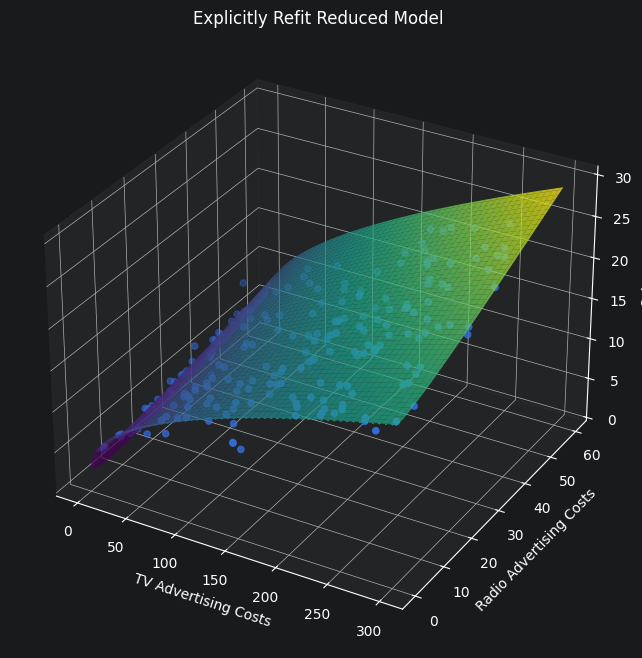

In [11]:
# Refit the reduced hierarchical model used for the 3D visualization.
# TV and Radio main effects are retained because the model includes TV:Radio.
reduced_formula = 'Sales ~ TV + Radio + np.sqrt(TV) + np.sqrt(Radio) + TV:Radio'
model_reduced = smf.ols(reduced_formula, data=advert).fit()
print(model_reduced.summary())

tv_grid = np.linspace(0, 300, 100)
radio_grid = np.linspace(0, 60, 100)
tv_grid, radio_grid = np.meshgrid(tv_grid, radio_grid)

p = model_reduced.params
sales_grid = (p['Intercept'] + p['TV']*tv_grid + p['Radio']*radio_grid
              + p['np.sqrt(TV)']*np.sqrt(tv_grid)
              + p['np.sqrt(Radio)']*np.sqrt(radio_grid)
              + p['TV:Radio']*tv_grid*radio_grid)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(advert['TV'], advert['Radio'], advert['Sales'], label='Data')
ax.plot_surface(tv_grid, radio_grid, sales_grid, cmap='viridis', alpha=0.75)
ax.set_xlabel('TV Advertising Costs')
ax.set_ylabel('Radio Advertising Costs')
ax.set_zlabel('Sales')
ax.set_title('Explicitly Refit Reduced Model')
plt.show()

In [12]:
# Conclusions:  Compare reduced linear, reduced quadratic, and reduced square-root models
print(f"Reduced linear model: RSS={RSS_reduced_linear:.3f}, R^2={R2_reduced_linear:.3f}, R^2_adj={R2_adj_reduced_linear:.3f}, F={F_statistic_reduced_linear:.3f}")
print(f"Reduced quadratic model: RSS={RSS_quadratic_reduced:.3f}, R^2={R2_quadratic_reduced:.3f}, R^2_adj={R2_adj_quadratic_reduced:.3f}, F={F_statistic_quadratic_reduced:.3f}")
print(f"Reduced square-root model: RSS={RSS_sqrt_reduced:.3f}, R^2={R2_sqrt_reduced:.3f}, R^2_adj={R2_adj_sqrt_reduced:.3f}, F={F_statistic_sqrt_reduced:.3f}")

# calculate dof for each model
dof_reduced_linear = len(advert) - 3
dof_reduced_quadratic = len(advert) - len(model_reduced.params)
dof_reduced_sqrt = len(advert) - len(model_reduced.params)

# now calculate RSS per dof
RSS_per_dof_reduced_linear = RSS_reduced_linear / dof_reduced_linear
RSS_per_dof_reduced_quadratic = RSS_quadratic_reduced / dof_reduced_quadratic
RSS_per_dof_reduced_sqrt = RSS_sqrt_reduced / dof_reduced_sqrt

print(f"Reduced linear model: RSS/dof={RSS_per_dof_reduced_linear:.3f}")
print(f"Reduced quadratic model: RSS/dof={RSS_per_dof_reduced_quadratic:.3f}")
print(f"Reduced square-root model: RSS/dof={RSS_per_dof_reduced_sqrt:.3f}")




Reduced linear model: RSS=541.211, R^2=0.903, R^2_adj=0.902, F=912.686
Reduced quadratic model: RSS=358.331, R^2=0.935, R^2_adj=0.933, F=559.348
Reduced square-root model: RSS=346.302, R^2=0.937, R^2_adj=0.936, F=580.597
Reduced linear model: RSS/dof=2.747
Reduced quadratic model: RSS/dof=1.847
Reduced square-root model: RSS/dof=1.785
